In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
import os

# Change YOUR_USERNAME to your actual Windows username
file_path = r'C:\Users\ASUS\Documents\skycity_project\data\SkyCity Auckland Restaurants & Bars.csv'

df = pd.read_csv(file_path)
print("File loaded successfully!")
print(df.shape)

File loaded successfully!
(1696, 30)


In [12]:
print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.isnull().sum())

(1696, 30)
CuisineType                  str
RestaurantID               int64
RestaurantName               str
Segment                      str
Subregion                    str
GrowthFactor             float64
AOV                      float64
MonthlyOrders              int64
InStoreOrders              int64
InStoreRevenue           float64
UberEatsOrders             int64
DoorDashOrders             int64
SelfDeliveryOrders         int64
UberEatsRevenue          float64
DoorDashRevenue          float64
SelfDeliveryRevenue      float64
COGSRate                 float64
OPEXRate                 float64
CommissionRate           float64
DeliveryRadiusKM           int64
DeliveryCostPerOrder     float64
SD_DeliveryTotalCost     float64
InStoreNetProfit         float64
UberEatsNetProfit        float64
DoorDashNetProfit        float64
SelfDeliveryNetProfit    float64
InStoreShare             float64
UE_share                 float64
DD_share                 float64
SD_share                 float64

In [13]:
df['TotalNetProfit'] = (df['InStoreNetProfit'] + df['UberEatsNetProfit'] +
                        df['DoorDashNetProfit'] + df['SelfDeliveryNetProfit'])
df['NetProfitPerOrder'] = df['TotalNetProfit'] / df['MonthlyOrders']

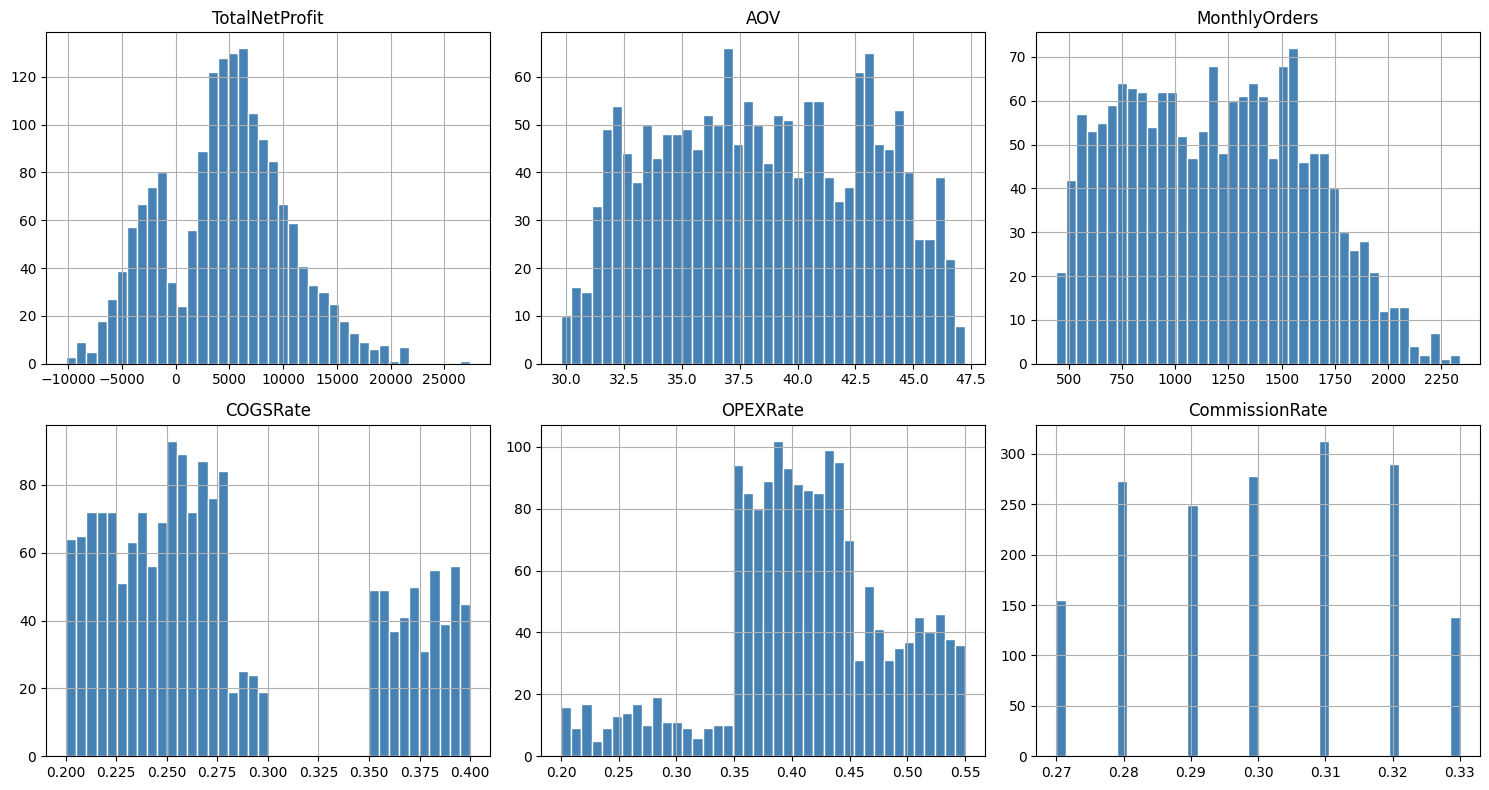

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), ['TotalNetProfit', 'AOV', 'MonthlyOrders',
                                      'COGSRate', 'OPEXRate', 'CommissionRate']):
    df[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150)
plt.show()

In [15]:
print(df.groupby('Segment')['TotalNetProfit'].mean().sort_values(ascending=False))
print(df.groupby('CuisineType')['TotalNetProfit'].mean().sort_values(ascending=False))

Segment
Ghost Kitchen    9051.098782
Cafe             7481.548413
QSR              6656.200921
Full-service    -2880.039447
Name: TotalNetProfit, dtype: float64
CuisineType
Pizza                   7305.377854
Burgers                 6207.182613
Chinese                 4642.744358
Chicken Dishes          3772.889459
Japanese                3686.458000
Thai                    3562.757667
Indian                  3438.303739
Kebabs/Mediterranean    2198.330419
Name: TotalNetProfit, dtype: float64


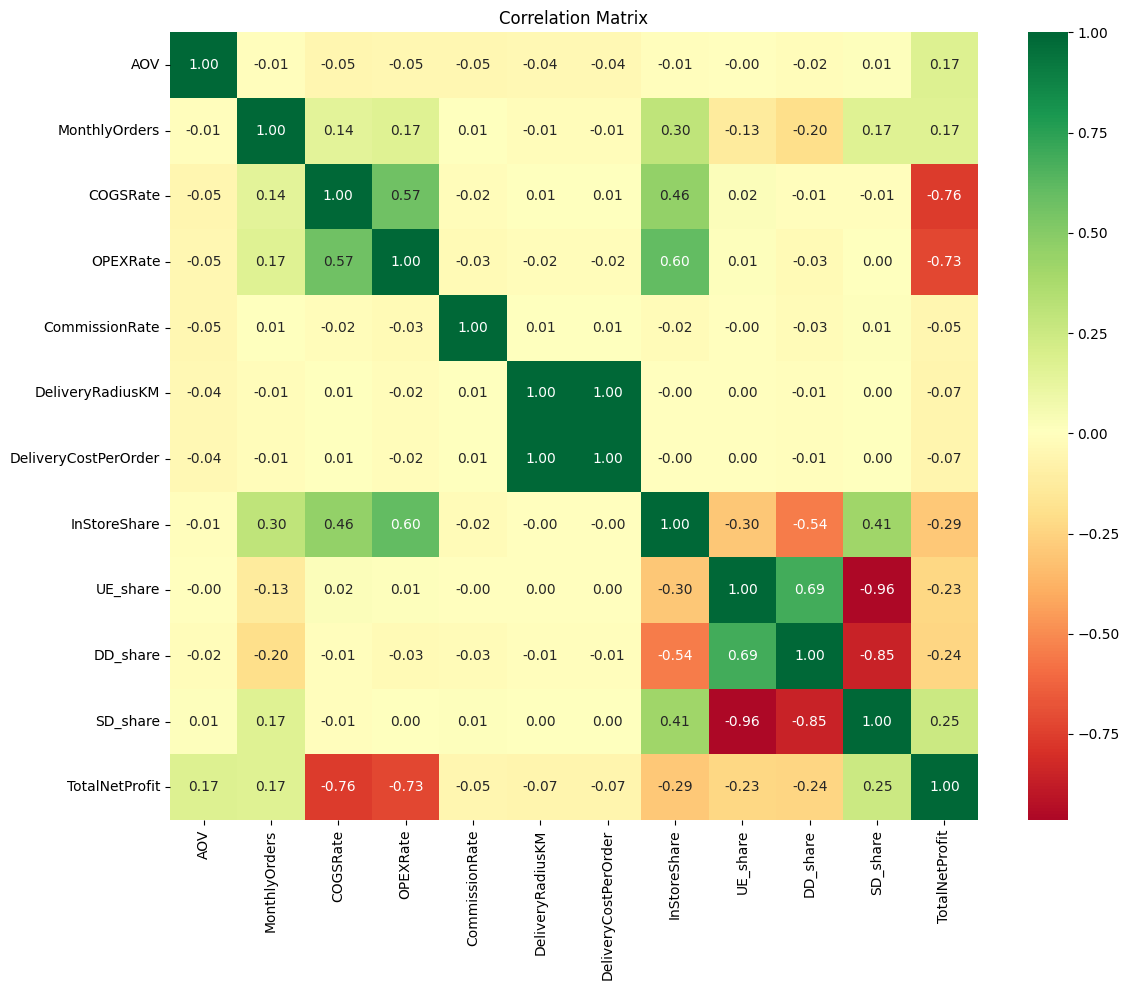

In [16]:
num_cols = ['AOV','MonthlyOrders','COGSRate','OPEXRate','CommissionRate',
            'DeliveryRadiusKM','DeliveryCostPerOrder','InStoreShare',
            'UE_share','DD_share','SD_share','TotalNetProfit']
corr = df[num_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150)
plt.show()